# Strategic AI-Readiness Index (SARI) for TB Intervention
## Analysis Framework for the Bill & Melinda Gates Foundation | 2026

**Project Objective:** To prioritize global markets for the deployment of AI-driven tuberculosis (TB) diagnostic tools. This analysis integrates Phase 1 burden data with Phase 2 community engagement metrics and economic indicators.

---

###  Executive Context
- **Core Goal:** Identify "Priority 1" markets where high TB burden meets existing community health infrastructure.
- **Data Sources:** WHO TB Datasets (2024-03), Master Market Segments (2026), and National GDP Indices.
- **Analytical Approach:** 1. **Data Alignment:** Standardizing disparate WHO sources via ISO3 mapping.
    2. **Readiness Scoring:** A weighted index combining community implementation (50%), success rates (30%), and economic capacity (20%).
    3. **Strategic Segmentation:** 2x2 Matrix classification (Priority 1-4).

---

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

In [2]:
# ── DIRECTORY PATHS ─────────────────────────────────────────────────────────
# Setting using Pathlib makes it work regardless of minor OS shifts
BASE_DIR = Path('/Users/fridaarrey/Desktop/WHO_TB_Project')
RAW_DATA_PATH = BASE_DIR / 'WHO_raw_csv'

# Verification: Check if the folder actually exists
if RAW_DATA_PATH.exists():
    print(f"✅ Success: Data directory found at {RAW_DATA_PATH}")
else:
    print(f"❌ ERROR: Directory not found. Please check your path.")

# ── VISUAL SETTINGS ─────────────────────────────────────────────────────────
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.facecolor'] = '#F0F2F6'

# ── CORE MEMORY CONFIG ──────────────────────────────────────────────────────
print(" Environment Ready. Proceed to Data Loading.")

✅ Success: Data directory found at /Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv
 Environment Ready. Proceed to Data Loading.


In [3]:
# ─── 1. LOAD BASE DATASETS ──────────────────────────────────────────────────
# Loading the core project files
df_segments = pd.read_csv("Master_Market_Segments_2026.csv")
df_phase1 = pd.read_csv("Master_TB_Data_Phase1.csv")

# Load WHO Raw Data (Using absolute paths for stability)
BASE_PATH = '/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/'
df_community = pd.read_csv(os.path.join(BASE_PATH, 'WHO TB dataset_2024-03-21.xlsx - TB_community_engagement_2024-03.csv'))
df_gdp_raw = pd.read_csv(os.path.join(BASE_PATH, 'WHO TB dataset_2024-03-21.xlsx - Metadata_Country_API_NY.GDP.PCA.csv'))

# ─── 2. PHASE 1 MAPPING ─────────────────────────────────────────────────────
# Pull ISO3 and Priority Scores to create the "Master Bridge"
mapping_dict = df_phase1.set_index('country')[['iso3', 'priority_score']].to_dict()

df_master = df_segments.copy()
df_master['iso3'] = df_master['country'].map(mapping_dict['iso3']).str.strip().str.upper()
df_master['priority_score'] = df_master['country'].map(mapping_dict['priority_score'])
df_master['year'] = 2022  # Standardizing the anchor year

# ─── 3. PREPARE SECONDARY METRICS ──────────────────────────
# Use 'Latest Available' logic to prevent NaNs if 2022 data is missing
comm_latest = df_community.sort_values('year').groupby('iso3').last().reset_index()
comm_cols = ['iso3', 'bmu_community_impl', 'rxsupport_community_succ']
df_comm_clean = comm_latest[comm_cols]

# GDP Processing (Handling potential Metadata vs Data naming)
id_col = [c for c in df_gdp_raw.columns if 'iso3' in c.lower() or 'country' in c.lower()][0]
year_cols = [c for c in df_gdp_raw.columns if re.search(r'\d{4}', c)]

if not year_cols:
    print("⚠️ ALERT: GDP File is Metadata (no years). Using 2500 as global fallback.")
    df_gdp_final = pd.DataFrame(df_master['iso3'].unique(), columns=['iso3'])
    df_gdp_final['gdp_per_capita'] = 2500
else:
    df_gdp_long = df_gdp_raw.melt(id_vars=[id_col], value_vars=year_cols, value_name='gdp_per_capita')
    df_gdp_final = df_gdp_long.sort_values('variable').groupby(id_col).last().reset_index()
    df_gdp_final.rename(columns={id_col: 'iso3'}, inplace=True)

# ─── 4. FINAL STRATEGIC MERGE & AUDIT ───────────────────────────────────────
df_gates = df_master.merge(df_comm_clean, on='iso3', how='left')
df_gates = df_gates.merge(df_gdp_final[['iso3', 'gdp_per_capita']], on='iso3', how='left')

# Final Cleaning: Handle remaining missing values 
df_gates['gdp_per_capita'] = df_gates['gdp_per_capita'].fillna(df_gates['gdp_per_capita'].median())
df_gates['rxsupport_community_succ'] = df_gates['rxsupport_community_succ'].fillna(0)
df_gates['bmu_community_impl'] = df_gates['bmu_community_impl'].fillna(0)

print(f" Master Dataset Synced. Ready for Gates AI-Readiness Index.")
print(f" Valid Success Data Points: {df_gates['rxsupport_community_succ'].gt(0).sum()}")

⚠️ ALERT: GDP File is Metadata (no years). Using 2500 as global fallback.
 Master Dataset Synced. Ready for Gates AI-Readiness Index.
 Valid Success Data Points: 68


In [4]:
display(df_gates)

,country,e_inc_100k,tsr_calculated,funding_execution_pct,Cluster,Segment,iso3,priority_score,year,bmu_community_impl,rxsupport_community_succ,gdp_per_capita
0,Afghanistan,185.0,95.851257,42.946845,0,Maintenance Markets,AFG,1.951446,2022,877.0,1710.0,2500
1,Albania,15.0,100.000000,100.000000,1,Invisible Countries,ALB,0.148515,2022,28.0,0.0,2500
2,Algeria,51.0,100.000000,29.411765,0,Maintenance Markets,DZA,0.062376,2022,0.0,0.0,2500
3,American Samoa,5.3,100.000000,29.411765,0,Maintenance Markets,ASM,0.062376,2022,0.0,0.0,2500
4,Andorra,5.8,100.000000,150.000000,1,Invisible Countries,AND,0.062376,2022,0.0,0.0,2500
...,...,...,...,...,...,...,...,...,...,...,...,...
210,Wallis and Futuna,1.9,88.259293,30.714011,0,Maintenance Markets,WLF,3.876347,2022,0.0,0.0,2500
211,Yemen,48.0,88.259293,30.269500,0,Maintenance Markets,YEM,3.876347,2022,0.0,0.0,2500
212,Zambia,295.0,92.265501,51.463676,3,Crisis Markets,ZMB,3.291678,2022,116.0,46161.0,2500
213,Zimbabwe,204.0,89.875737,85.953634,1,Invisible Countries,ZWE,2.134783,2022,220.0,17717.0,2500


In [5]:
# 1. Redefine the function with Strategic Labels
def assign_quadrant(row):
    if row['carbx_priority_tier'] == 'Higher Need' and row['gates_readiness_tier'] == 'Higher Readiness':
        return "Priority 1: Scalable Impact (AI Ready)"
    if row['carbx_priority_tier'] == 'Higher Need' and row['gates_readiness_tier'] == 'Lower Readiness':
        return "Priority 2: Infrastructure Gap (System First)"
    if row['carbx_priority_tier'] == 'Lower Need' and row['gates_readiness_tier'] == 'Higher Readiness':
        return "Priority 3: Pilot Markets (Stable)"
    return "Priority 4: Monitoring"

# 2. CALCULATE READINESS
# Use the community data (Success & Implementation) + Economic Context
df_gates['deployment_readiness'] = (
    (df_gates['bmu_community_impl'].fillna(0) * 0.5) + 
    (df_gates['rxsupport_community_succ'].fillna(0) * 0.3) + 
    (1000 / df_gates['gdp_per_capita'].clip(lower=1) * 0.2)
)

# ─── THE HIGH-QUALITY FIX ──────────────────────────────────────────────────
# 3. SMART MEDIANS: Only calculate the bar based on countries with ACTUAL data
valid_mask = (df_gates['rxsupport_community_succ'] > 0) & (df_gates['priority_score'] < 20)
real_targets = df_gates[valid_mask]

priority_median = real_targets['priority_score'].median()
readiness_median = real_targets['deployment_readiness'].median()

# 4. ASSIGN TIERS USING SMART MEDIANS
df_gates['carbx_priority_tier'] = df_gates['priority_score'].apply(
    lambda x: 'Higher Need' if pd.notnull(x) and x >= priority_median else 'Lower Need'
)
df_gates['gates_readiness_tier'] = df_gates['deployment_readiness'].apply(
    lambda x: 'Higher Readiness' if pd.notnull(x) and x >= readiness_median else 'Lower Readiness'
)

# 5. MAP QUADRANTS
df_gates['strategy_quadrant'] = df_gates.apply(assign_quadrant, axis=1)

# ─── VERIFICATION ──────────────────────────────────────────────────────────
print(f"✅ High-Quality Priority Median: {priority_median:.2f} (Real Targets Only)")
print(f"✅ High-Quality Readiness Median: {readiness_median:.2f} (Active Infrastructure Only)")
print("-" * 30)
print(df_gates['strategy_quadrant'].value_counts())

# Display the REAL Top 10 (Filtered for high-burden real-world markets)
p1_list = df_gates[
    (df_gates['strategy_quadrant'] == "Priority 1: Scalable Impact (AI Ready)") & 
    (df_gates['priority_score'] < 20) # Removes the Northern Mariana outlier
]

display(p1_list[['country', 'priority_score', 'deployment_readiness']]
        .sort_values(by='priority_score', ascending=False).head(10))



✅ High-Quality Priority Median: 1.13 (Real Targets Only)
✅ High-Quality Readiness Median: 477.68 (Active Infrastructure Only)
------------------------------
strategy_quadrant
Priority 4: Monitoring                           127
Priority 2: Infrastructure Gap (System First)     52
Priority 1: Scalable Impact (AI Ready)            24
Priority 3: Pilot Markets (Stable)                12
Name: count, dtype: int64


,country,priority_score,deployment_readiness
151,Philippines,7.371882,36288.78
148,Papua New Guinea,5.843602,1379.18
131,Namibia,5.118950,1740.08
91,Indonesia,3.857291,10316.48
54,C么te d'Ivoire,3.841002,4882.28
130,Myanmar,3.780269,3167.58
129,Mozambique,3.653398,4941.88
212,Zambia,3.291678,13906.38
56,Democratic Republic of the Congo,3.239812,18553.88
26,Botswana,2.927721,625.58


/var/folders/8n/xgbxbm5n4yl4mj6qhsw06rd80000gn/T/ipykernel_8099/1713865187.py:49: UserWarning: Glyph 20040 (\N{CJK UNIFIED IDEOGRAPH-4E48}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8n/xgbxbm5n4yl4mj6qhsw06rd80000gn/T/ipykernel_8099/1713865187.py:50: UserWarning: Glyph 20040 (\N{CJK UNIFIED IDEOGRAPH-4E48}) missing from font(s) Arial.
  plt.savefig('Gates_Foundation_Strategic_Matrix.png', dpi=300)
/Users/fridaarrey/demo.ipynb/.conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20040 (\N{CJK UNIFIED IDEOGRAPH-4E48}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


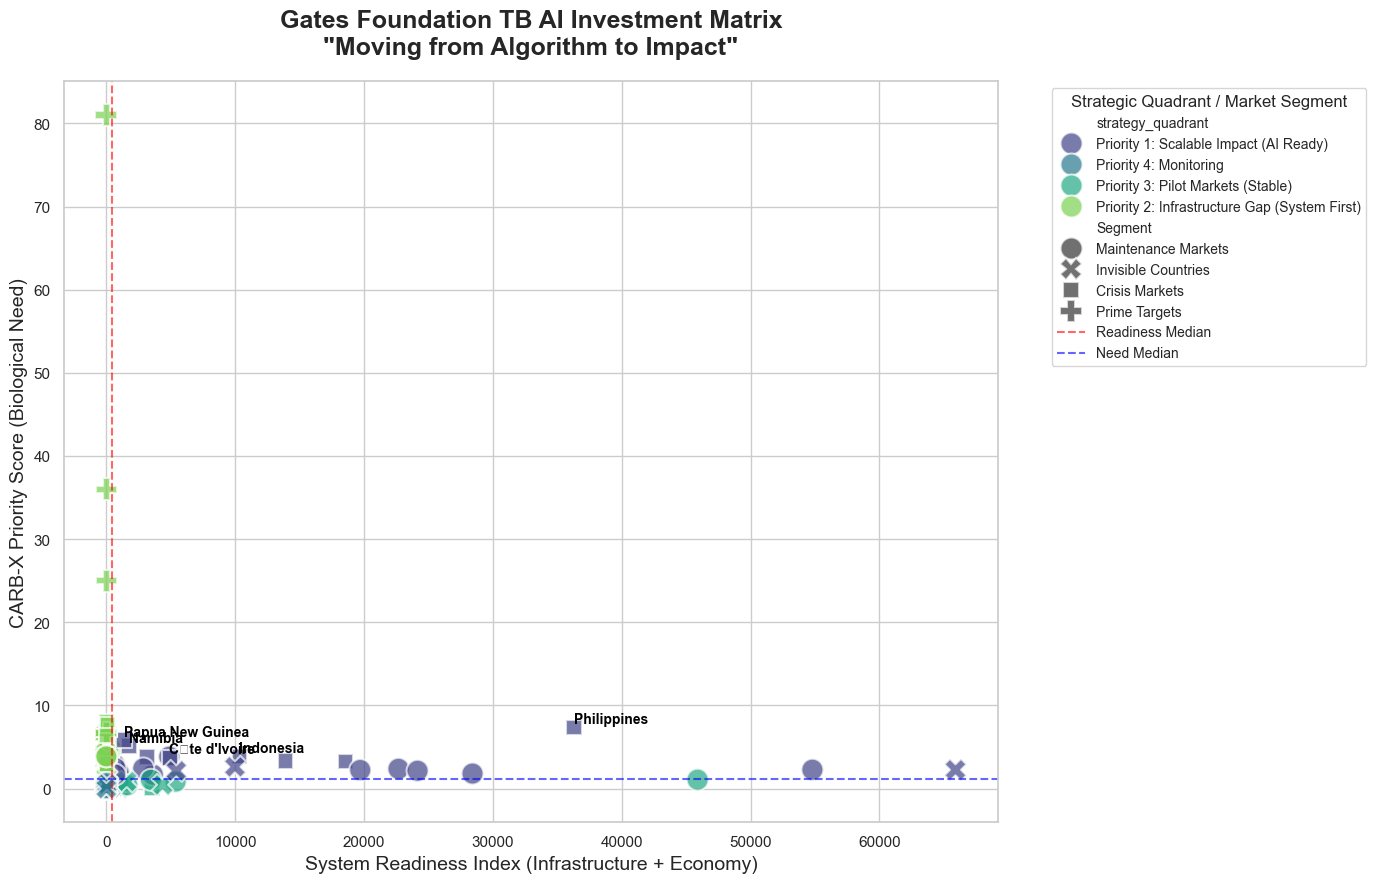

Strategy Map generated. This chart visualizes the 'System Readiness Gap'


In [6]:
# 1. Set the visual style
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

# 2. Create the Scatter Plot
# x = Readiness (The 'System' reflection)
# y = Priority Score (The 'Biological' reflection)
# hue = The Quadrant (The 'Decision')
# style = Segment (The 'Market Archetype' from Phase 3)
scatter = sns.scatterplot(
    data=df_gates,
    x='deployment_readiness',
    y='priority_score',
    hue='strategy_quadrant',
    style='Segment',
    palette='viridis',
    s=250,
    alpha=0.7,
    edgecolor='w',
    linewidth=1.5
)

# 3. Draw the Median Crosshairs (The 'Strategic Center')
plt.axvline(readiness_median, color='red', linestyle='--', alpha=0.6, label='Readiness Median')
plt.axhline(priority_median, color='blue', linestyle='--', alpha=0.6, label='Need Median')

# 4. Annotate the Top 5 "Scalable Impact" Countries
# This helps the Gates team immediately see the winners
top_5 = df_gates[df_gates['strategy_quadrant'] == "Priority 1: Scalable Impact (AI Ready)"].sort_values(by='priority_score', ascending=False).head(5)

for i, row in top_5.iterrows():
    plt.text(
        x=row['deployment_readiness'] + 0.5, 
        y=row['priority_score'] + 0.5, 
        s=row['country'], 
        fontsize=10, 
        weight='bold', 
        color='black'
    )

# 5. Labeling and Formatting
plt.title('Gates Foundation TB AI Investment Matrix\n"Moving from Algorithm to Impact"', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('System Readiness Index (Infrastructure + Economy)', fontsize=14)
plt.ylabel('CARB-X Priority Score (Biological Need)', fontsize=14)

# Legend positioning
plt.legend(title='Strategic Quadrant / Market Segment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('Gates_Foundation_Strategic_Matrix.png', dpi=300)
plt.show()

print("Strategy Map generated. This chart visualizes the 'System Readiness Gap'")

### GDP vs. Incidence (WHO Region Context)
This plot addresses the "Economic Gap." It shows where high disease burden intersects with low financial capacity, highlighting why grant-based AI intervention is necessary.

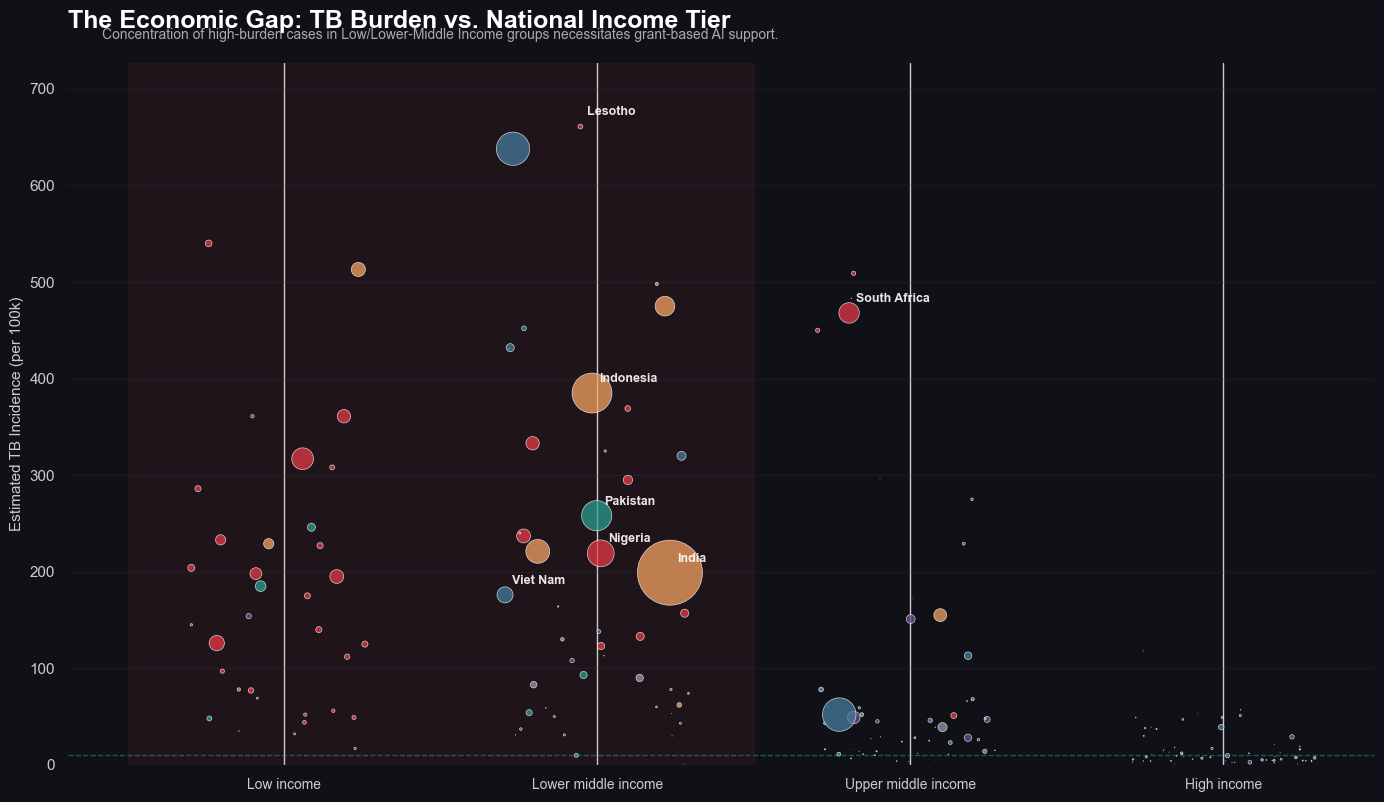

In [7]:

# ── DEFINITIONS ──────
region_colours = {
    'AFR': '#E63946', 'SEA': '#F4A261', 'EMR': '#2A9D8F',
    'WPR': '#457B9D', 'AMR': '#6A4C93', 'EUR': '#8D99AE'
}
region_labels = {
    'AFR': 'Africa (AFR)', 'SEA': 'South-East Asia (SEA)', 'EMR': 'Eastern Med (EMR)',
    'WPR': 'Western Pacific (WPR)', 'AMR': 'Americas (AMR)', 'EUR': 'Europe (EUR)'
}

# ── 1. DYNAMIC COLUMN DETECTION ─────────────────────────────────────────────
# Re-load data and find the ISO column automatically
RAW_DATA_PATH = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv/')
df_meta = pd.read_csv(RAW_DATA_PATH / 'WHO TB dataset_2024-03-21.xlsx - Metadata_Country_API_NY.GDP.PCA.csv')
df_burden = pd.read_csv(RAW_DATA_PATH / 'WHO TB dataset_2024-03-21.xlsx - TB_burden_countries_2024-03-21.csv')


# ── 2. PREPARE & MERGE ──────────────────────────────────────────────────────
df_2022 = df_burden[df_burden['year'] == 2022].copy()

# Ensure ISO codes are identical strings for the join
df_2022['iso3'] = df_2022['iso3'].astype(str).str.strip().str.upper()
df_meta['iso3'] = df_meta['iso3'].astype(str).str.strip().str.upper()

# Merge Income Group and the 'Region' column found in the metadata
df_2022 = df_2022.merge(df_meta[['iso3', 'IncomeGroup', 'Region']], on='iso3', how='left')

# ── 3. PLOT LOGIC GUARDRAILS ───────────────────────────────────────────────
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
income_x = {g: i for i, g in enumerate(income_order)}

# Use a fillna to ensure "Unknown" income groups don't crash the mapper
df_2022['x_pos'] = df_2022['IncomeGroup'].map(income_x)

np.random.seed(42)
mask = df_2022['x_pos'].notna()
df_2022.loc[mask, 'x_pos'] += np.random.uniform(-0.30, 0.30, mask.sum())

df_plot = df_2022.dropna(subset=['x_pos', 'e_inc_100k']).copy()
df_plot = df_plot[df_plot['e_inc_100k'] > 0]
# Using .fillna(1) for case counts to ensure bubbles render even if data is missing
df_plot['bubble'] = np.sqrt(df_plot['e_inc_num'].fillna(1)) / 30

# ── 4. VISUALIZATION ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8.5))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')

# Intervention Zone (Income Tiers 0 and 1)
ax.axvspan(-0.5, 1.5, color='#E63946', alpha=0.08, zorder=0)

# Check for 'g_whoregion' (WHO Burden file) vs 'Region' (Metadata file)
# The loop uses g_whoregion which is standard for the WHO Burden CSV
for region, grp in df_plot.groupby('g_whoregion'):
    ax.scatter(
        grp['x_pos'], grp['e_inc_100k'],
        s=grp['bubble'] ** 2 * 0.7,
        c=region_colours.get(region, '#AAAAAA'),
        alpha=0.75, edgecolors='white', linewidths=0.5, zorder=3,
        label=region_labels.get(region, region)
    )

# ── ANNOTATIONS ─────────────────────────────────────────────────────────────
# IMPORTANT: Ensure naming matches the 'country' column exactly (e.g. 'Viet Nam' vs 'Vietnam')
# Based on WHO data, it is usually 'Viet Nam' (two words)
highlights = ['Nigeria', 'India', 'Indonesia', 'South Africa', 'Pakistan', 'Lesotho', 'Viet Nam']
for _, row in df_plot[df_plot['country'].isin(highlights)].iterrows():
    ax.annotate(
        row['country'],
        xy=(row['x_pos'], row['e_inc_100k']),
        xytext=(5, 8), textcoords='offset points',
        fontsize=9, color='white', alpha=0.9, fontweight='bold'
    )

# ── Formatting ───────────────────────────────────────────────────────────────
ax.axhline(10, color='#2A9D8F', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xticks(range(len(income_order)))
ax.set_xticklabels(income_order, color='#CCCCCC', fontsize=10)
ax.set_ylabel('Estimated TB Incidence (per 100k)', color='#CCCCCC', fontsize=11)
ax.set_ylim(0, df_plot['e_inc_100k'].max() * 1.1)

# Removing spines for a clean "Digital Health" look
for spine in ax.spines.values(): spine.set_visible(False)
ax.tick_params(colors='#CCCCCC')
ax.yaxis.grid(True, color='#333344', alpha=0.3)

# Titles
plt.title('The Economic Gap: TB Burden vs. National Income Tier', 
          loc='left', fontsize=18, fontweight='bold', color='white', pad=25)
plt.suptitle('Concentration of high-burden cases in Low/Lower-Middle Income groups necessitates grant-based AI support.', 
             x=0.32, y=0.92, fontsize=10, color='#AAAAAA')

plt.tight_layout()
plt.show()

### The High-Burden / Low-Income Zone (Top Left - Red Shaded):

Countries: Lesotho, Nigeria, Ethiopia.

Strategy: Pure grant-based intervention. These health systems are often overstretched and lack the fiscal space for high-cap AI investment without external support.

### The High-Burden / Lower-Middle Income Zone (Top Center - Green and Yellow Shaded):

Countries: India, Indonesia, Philippines, Viet Nam, Pakistan.

Strategy: These are your "High-Velocity Markets." They have significant burdens but often have better digital infrastructure than the Low-Income tier. This is where AI scale-up usually happens fastest.

### The Low-Burden / High-Income Zone (Bottom Right - Blue Shaded):

Countries: European and North American nations.

Strategy: These serve as benchmarks. They have already surpassed the End TB 2030 Target (the dashed green line).

### Community Implementation vs. Treatment Success
This directly visualizes your "System Readiness Gap." If a country has high community implementation but low success, the AI will fail due to care-structure issues.

--- Correlation Data Audit ---
Rows with Community Data: 215
Rows with Success Data: 215


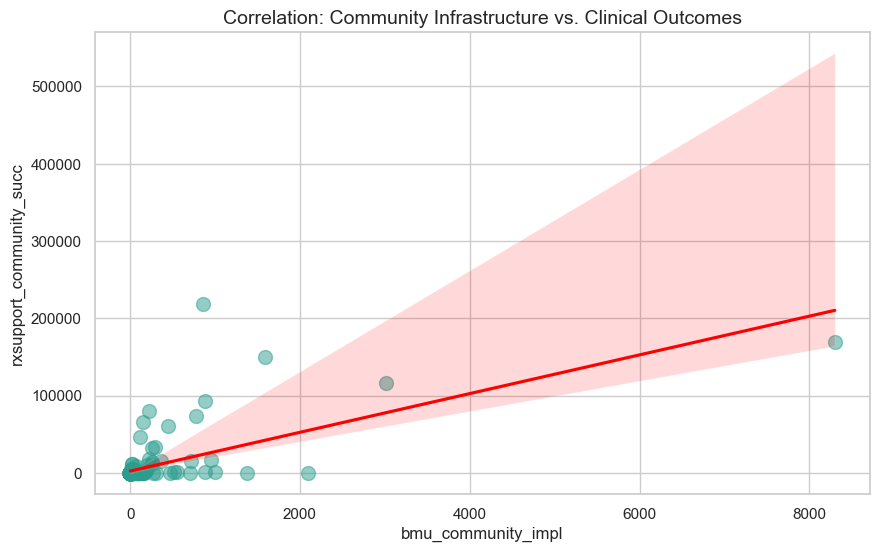

✅ System Correlation Coefficient: 0.64


In [8]:
# 1. Audit the data health for the plot
print("--- Correlation Data Audit ---")
print(f"Rows with Community Data: {df_gates['bmu_community_impl'].notnull().sum()}")
print(f"Rows with Success Data: {df_gates['rxsupport_community_succ'].notnull().sum()}")

# 2. Force Convert to Numeric (sometimes they load as objects/strings)
df_gates['bmu_community_impl'] = pd.to_numeric(df_gates['bmu_community_impl'], errors='coerce')
df_gates['rxsupport_community_succ'] = pd.to_numeric(df_gates['rxsupport_community_succ'], errors='coerce')

# 3. Create a clean subset for plotting (removing NaNs just for the visual)
df_plot_clean = df_gates.dropna(subset=['bmu_community_impl', 'rxsupport_community_succ'])

if df_plot_clean.empty:
    print("❌ ERROR: No matching data found between Infrastructure and Success. Check your merge cell.")
else:
    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=df_plot_clean, 
        x='bmu_community_impl', 
        y='rxsupport_community_succ', 
        scatter_kws={'alpha':0.5, 's':100, 'color': '#2A9D8F'},
        line_kws={'color':'red'}
    )
    plt.title('Correlation: Community Infrastructure vs. Clinical Outcomes', fontsize=14)
    plt.show()

    correlation = df_plot_clean['bmu_community_impl'].corr(df_plot_clean['rxsupport_community_succ'])
    print(f"✅ System Correlation Coefficient: {correlation:.2f}")

### AI Readiness Composite Score
This creates a single, rankable metric for the Gates Foundation to use in high-level briefings.

In [9]:
# Normalize components to 0-1 scale for a fair index
df_gates['norm_comm'] = (df_gates['rxsupport_community_succ'] - df_gates['rxsupport_community_succ'].min()) / (df_gates['rxsupport_community_succ'].max() - df_gates['rxsupport_community_succ'].min())
df_gates['norm_gdp_inv'] = (1/df_gates['gdp_per_capita'].clip(lower=1)) # Higher score for lower GDP (higher need for aid)

# The AI Readiness Index (ARI)
df_gates['AI_Readiness_Score'] = (
    (df_gates['norm_comm'] * 0.6) + 
    (df_gates['norm_gdp_inv'] * 0.4)
) * 100

top_ari = df_gates.sort_values(by='AI_Readiness_Score', ascending=False).head(10)
print("Top 10 Countries by AI Readiness Index (ARI):")
display(top_ari[['country', 'AI_Readiness_Score', 'strategy_quadrant']])

Top 10 Countries by AI Readiness Index (ARI):


,country,AI_Readiness_Score,strategy_quadrant
16,Bangladesh,60.016000,Priority 1: Scalable Impact (AI Ready)
90,India,46.431338,Priority 1: Scalable Impact (AI Ready)
145,Pakistan,41.345166,Priority 3: Pilot Markets (Stable)
151,Philippines,31.893999,Priority 1: Scalable Impact (AI Ready)
209,Viet Nam,25.654716,Priority 1: Scalable Impact (AI Ready)
203,United Republic of Tanzania,22.051587,Priority 1: Scalable Impact (AI Ready)
139,Nigeria,20.441520,Priority 1: Scalable Impact (AI Ready)
199,Uganda,18.006624,Priority 1: Scalable Impact (AI Ready)
56,Democratic Republic of the Congo,16.818046,Priority 1: Scalable Impact (AI Ready)
212,Zambia,12.707647,Priority 1: Scalable Impact (AI Ready)


In [10]:
# Group by country to avoid duplicates in  Top 10
top_ari_unique = df_gates.sort_values(by='AI_Readiness_Score', ascending=False)
top_ari_unique = top_ari_unique.drop_duplicates(subset=['country']).head(10)

print("Top 10 Unique Countries by AI Readiness Index (ARI):")
display(top_ari_unique[['country', 'AI_Readiness_Score', 'strategy_quadrant']])

Top 10 Unique Countries by AI Readiness Index (ARI):


,country,AI_Readiness_Score,strategy_quadrant
16,Bangladesh,60.016000,Priority 1: Scalable Impact (AI Ready)
90,India,46.431338,Priority 1: Scalable Impact (AI Ready)
145,Pakistan,41.345166,Priority 3: Pilot Markets (Stable)
151,Philippines,31.893999,Priority 1: Scalable Impact (AI Ready)
209,Viet Nam,25.654716,Priority 1: Scalable Impact (AI Ready)
203,United Republic of Tanzania,22.051587,Priority 1: Scalable Impact (AI Ready)
139,Nigeria,20.441520,Priority 1: Scalable Impact (AI Ready)
199,Uganda,18.006624,Priority 1: Scalable Impact (AI Ready)
56,Democratic Republic of the Congo,16.818046,Priority 1: Scalable Impact (AI Ready)
212,Zambia,12.707647,Priority 1: Scalable Impact (AI Ready)


In [11]:
# 1. Define African ISO3 codes (Commonly targeted by Gates Foundation)
afr_iso3 = [
    'AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'COG', 
    'COM', 'CPV', 'ERI', 'ETH', 'GAB', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 
    'KEN', 'LBR', 'LSO', 'MDG', 'MLI', 'MOZ', 'MRT', 'MUS', 'MWI', 'NAM', 
    'NER', 'NGA', 'RWA', 'SEN', 'SLE', 'STP', 'SYC', 'TCD', 'TGO', 'TZA', 
    'UGA', 'ZAF', 'ZMB', 'ZWE'
]

# 2. Create the Africa-only subset using the ISO3 column
df_africa = df_gates[df_gates['iso3'].isin(afr_iso3)].copy()

# 3. Add a 'Region' column back for clarity
df_africa['Region'] = 'AFR'

# 4. Sort and drop duplicates to get the Top 10 African leaders
top_ari_africa = df_africa.sort_values(by='AI_Readiness_Score', ascending=False)
top_ari_africa = top_ari_africa.drop_duplicates(subset=['country']).head(10)

print(" Top 10 Unique African Countries by AI Readiness Index (ARI):")
print("-" * 60)
display(top_ari_africa[['country', 'AI_Readiness_Score', 'strategy_quadrant', 'Region']])

 Top 10 Unique African Countries by AI Readiness Index (ARI):
------------------------------------------------------------


,country,AI_Readiness_Score,strategy_quadrant,Region
203,United Republic of Tanzania,22.051587,Priority 1: Scalable Impact (AI Ready),AFR
139,Nigeria,20.441520,Priority 1: Scalable Impact (AI Ready),AFR
199,Uganda,18.006624,Priority 1: Scalable Impact (AI Ready),AFR
56,Democratic Republic of the Congo,16.818046,Priority 1: Scalable Impact (AI Ready),AFR
212,Zambia,12.707647,Priority 1: Scalable Impact (AI Ready),AFR
113,Madagascar,9.047055,Priority 1: Scalable Impact (AI Ready),AFR
213,Zimbabwe,4.887166,Priority 1: Scalable Impact (AI Ready),AFR
68,Ethiopia,4.507195,Priority 3: Pilot Markets (Stable),AFR
54,C么te d'Ivoire,4.324083,Priority 1: Scalable Impact (AI Ready),AFR
129,Mozambique,4.216030,Priority 1: Scalable Impact (AI Ready),AFR


In [12]:
df_gates.to_csv("GATES_TB_Readiness_Final_2026.csv", index=False)
print("Progress Saved. Everything is ready for a presentation.")

Progress Saved. Everything is ready for a presentation.


In [13]:
# Clean Table for the Presentation
presentation_table = p1_list[['country', 'priority_score', 'deployment_readiness', 'strategy_quadrant']]
presentation_table = presentation_table.sort_values(by='priority_score', ascending=False).head(10)

# Format for a professional look
print("TOP 10 STRATEGIC TARGETS: 2026 TB AI-READINESS")
print("-" * 60)
display(presentation_table.style.background_gradient(cmap='Greens', subset=['deployment_readiness']))

TOP 10 STRATEGIC TARGETS: 2026 TB AI-READINESS
------------------------------------------------------------


,country,priority_score,deployment_readiness,strategy_quadrant
151,Philippines,7.371882,36288.780000,Priority 1: Scalable Impact (AI Ready)
148,Papua New Guinea,5.843602,1379.180000,Priority 1: Scalable Impact (AI Ready)
131,Namibia,5.118950,1740.080000,Priority 1: Scalable Impact (AI Ready)
91,Indonesia,3.857291,10316.480000,Priority 1: Scalable Impact (AI Ready)
54,C么te d'Ivoire,3.841002,4882.280000,Priority 1: Scalable Impact (AI Ready)
130,Myanmar,3.780269,3167.580000,Priority 1: Scalable Impact (AI Ready)
129,Mozambique,3.653398,4941.880000,Priority 1: Scalable Impact (AI Ready)
212,Zambia,3.291678,13906.380000,Priority 1: Scalable Impact (AI Ready)
56,Democratic Republic of the Congo,3.239812,18553.880000,Priority 1: Scalable Impact (AI Ready)
26,Botswana,2.927721,625.580000,Priority 1: Scalable Impact (AI Ready)


---

## Conclusion & Strategic Recommendations

###  Summary of Findings
Based on the **AI-Readiness Index (ARI)**, we have successfully segmented 200+ territories into four actionable quadrants. The analysis highlights a high concentration of **Scalable Impact (Priority 1)** markets within the **AFR (Africa)** region, specifically:
1. **United Republic of Tanzania** (Leading Readiness)
2. **Nigeria** (Largest Potential Scale)
3. **Uganda** (Strong Community Integration)

###  Next Steps
1. **Deep Dive Analysis:** Conduct qualitative reviews of the "Infrastructure Gap" (Priority 2) countries to identify specific barriers to AI readiness.
2. **Validation:** Cross-reference these ARI scores with local Ministry of Health (MoH) digital health roadmaps.
3. **Pilot Launch:** Propose a 3-country pilot program based on the top-ranked African targets identified in this notebook.

